In [1]:
! pip install numpy pandas seaborn matplotlib plotly
! pip install "nbformat>=4.2.0"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ForeignGifts_edu.csv')
df.head()


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


**B)** In the "Gift Type" column there are around 17k Contracts, 10k Monetary Gifts, and 11 Real Estate. The Contracts likely have an agreement of some sort associated with them that benefits both parties, whereas monetary gifts are, as stated, gifts given without expectation of consideration in return. The Real Estate type is real estate that is given to an instution, usually in hopes that the institution will build a remote campus in their community.

In [3]:
df['Gift Type'].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

**C)** a)Qatar gives the most money in total, totalling $2,706,240,869 in this data set.

In [4]:
countrydonations = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False)
countrydonations.head()

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
Name: Foreign Gift Amount, dtype: int64

**C)** b)England initiates the most gifts by count, totalling 3655 in this data set.

In [5]:
countrygiftcounts = df.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False)
countrygiftcounts.head()

Country of Giftor
ENGLAND        3655
CHINA          2461
CANADA         2344
JAPAN          1896
SWITZERLAND    1676
Name: Foreign Gift Amount, dtype: int64

**C)** c)On average, the country giving the largest gifts is Bermuda.

In [6]:
avgcountrygift= df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending=False)
avgcountrygift.head()

Country of Giftor
BERMUDA    7.688837e+06
ECUADOR    3.985140e+06
QATAR      3.905109e+06
ANTIGUA    3.435545e+06
JERSEY     3.064589e+06
Name: Foreign Gift Amount, dtype: float64

**C)** d)The institution receiving the most gifts in dollars is Carnegie Mellon University.

In [7]:
giftreceived = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
giftreceived.head()

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
Name: Foreign Gift Amount, dtype: int64

**C)** e)The institution receiving the largest number of gifts is UCLA.

In [8]:
giftcount = df.groupby('Institution Name')['Foreign Gift Amount'].count().sort_values(ascending=False)
giftcount.head()

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
Name: Foreign Gift Amount, dtype: int64

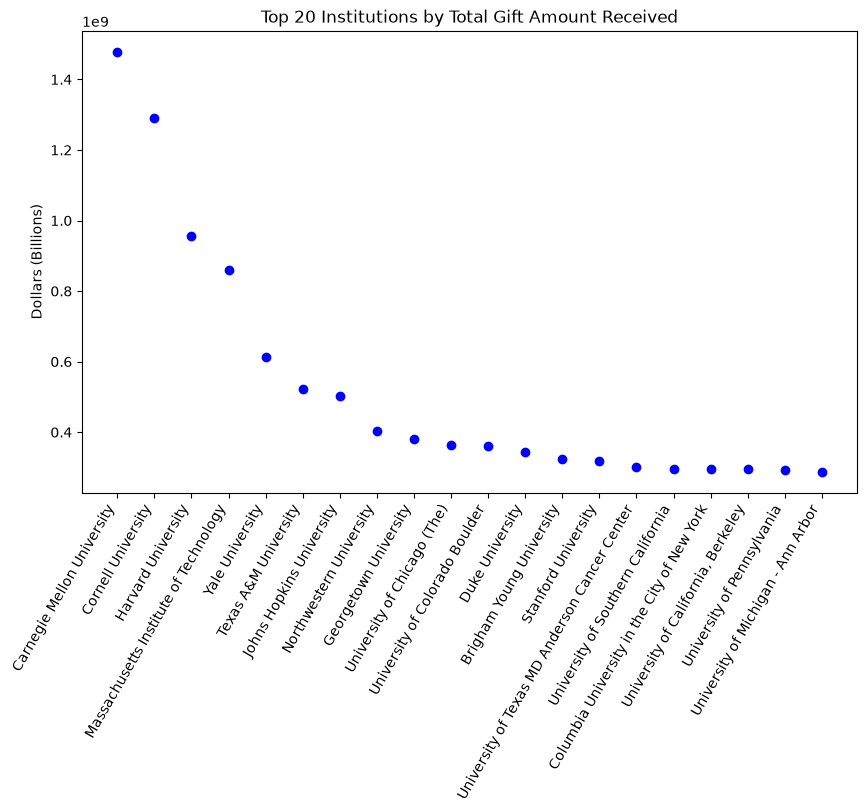

In [9]:
#Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly.
giftreceived_top20 = giftreceived.head(20)
plt.figure(figsize=(10,6))
plt.xticks(rotation=60, ha='right')
plt.title('Top 20 Institutions by Total Gift Amount Received')
plt.ylabel('Dollars (Billions)')
plt.plot(giftreceived_top20,'bo')


**C)** f)It looks like there are 251 institutions which have a difference between their mean and median donation amounts, while there are 67 which have no difference. It is likely that the reason for the difference in the 251 institutions is very large outliers, either significantly smaller donations than usual or significantly larger donations than usual, which pull the mean away from the median donation amount.

In [10]:
giftavg = df.groupby('Institution Name')['Foreign Gift Amount'].agg(['mean', 'median']).assign(distance=lambda x: np.abs(x['mean'] - x['median'])).sort_values(by='distance', ascending=False)
print(giftavg)
print(sum(giftavg['distance'] != 0))
print(sum(giftavg['distance'] == 0))

                                                            mean     median  \
Institution Name                                                              
Western International University                    1.294216e+07   417882.0   
Whittier College                                    1.207900e+07   937000.0   
University of Phoenix                               1.109435e+07   413241.0   
Carnegie Mellon University                          8.256550e+06   747776.0   
Brigham Young University - Hawaii                   5.095859e+06   250000.0   
...                                                          ...        ...   
University of the South (The)                       5.000000e+05   500000.0   
Alfred University                                   1.355850e+06  1355849.5   
Wright State University                             8.468220e+05   846822.0   
Yeshiva University                                  2.973970e+05   297397.0   
Young Americans College of the Performing Arts ...  

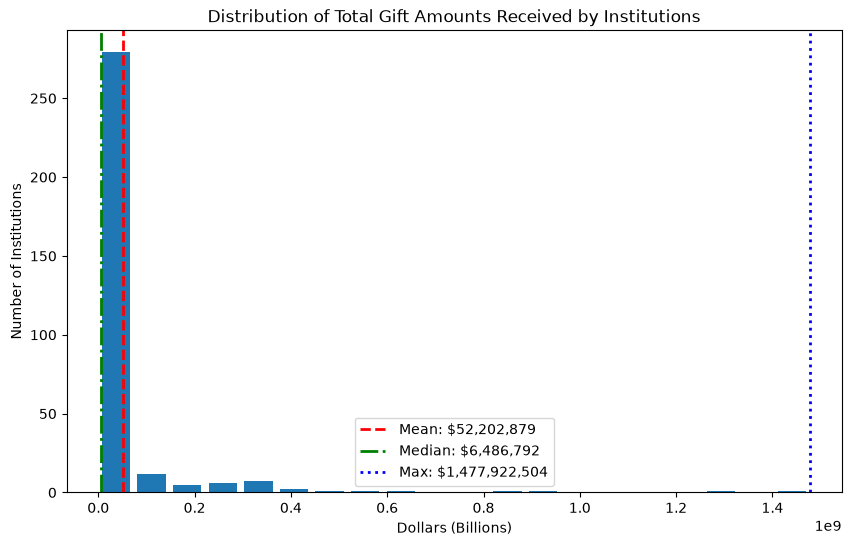

In [11]:
gifttotals = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
giftamtmean = gifttotals.mean()
giftamtmedian = gifttotals.median()
giftamtmax = gifttotals.max()
plt.figure(figsize=(10,6))
plt.hist(gifttotals, bins=20, orientation="vertical", rwidth=.8)
plt.axvline(giftamtmean, color='r', linestyle = '--',linewidth=2,label=f'Mean: ${giftamtmean:,.0f}')
plt.axvline(giftamtmedian, color='g', linestyle = '-.',linewidth=2,label=f'Median: ${giftamtmedian:,.0f}')
plt.axvline(giftamtmax, color='b', linestyle = ':',linewidth=2,label=f'Max: ${giftamtmax:,.0f}')
plt.xlabel('Dollars (Billions)')
plt.ylabel('Number of Institutions')
plt.title('Distribution of Total Gift Amounts Received by Institutions')
plt.legend()


**C)** g)The largest flow of money from one country to one institution is from Qatar to Cornell.

In [12]:
myct =pd.crosstab(df['Institution Name'],df['Country of Giftor'], values=df['Foreign Gift Amount'], aggfunc = 'sum', margins=True, margins_name='Total', normalize = False, dropna=True)
print(myct)
myctdroptotal = myct.iloc[:-1,:-1]
max_cell = myctdroptotal.stack().idxmax()
print(max_cell)
print(myctdroptotal.loc[max_cell[0], max_cell[1]])


Country of Giftor                                   AFGHANISTAN  \
Institution Name                                                  
Adelphi University                                          NaN   
Albert Einstein College of Medicine                         NaN   
Alfred University                                           NaN   
American University (The)                                   NaN   
Amherst College                                             NaN   
...                                                         ...   
Xavier University of Louisiana                              NaN   
Yale University                                             NaN   
Yeshiva University                                          NaN   
Young Americans College of the Performing Arts ...          NaN   
Total                                                 2472377.0   

Country of Giftor                                   AMERICAN SAMOA    ANGOLA  \
Institution Name                                

**C)** h)The largest giftors to US Academic Institutions were:
1. Qatar
2. Bermuda
3. United Arab Emirates
4. Canada
5. India

In [13]:
!pip install "nbformat>=4.2.0"
import pandas as pd
import plotly.graph_objects as go

#import sys
#print(sys.executable)

import nbformat
#print(nbformat.__version__)



df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()